# NB10 — Evaluación detallada de las 84 ejecuciones

**TFM · Máster Universitario en Inteligencia Artificial · VIU 2025-2026 · Víctor Rodríguez Rodríguez**

---

## Propósito
Analizar en profundidad las 84 ejecuciones: métricas de discriminación y calibración con intervalos de confianza bootstrap, comparaciones pareadas mediante DeLong, análisis estratificados por densidad, edad y BI-RADS original, y análisis post-hoc de agregación mama a estudio.

**Inputs**: `outputs/Predicciones/*_test.npy`, `*_oof.npy`, `*_meta.json`; `outputs/Features/metadata.csv` (NB03); anotaciones extra de VinDr-Mammo `breast-level_annotations.csv` (para BI-RADS por vista y edad DICOM).

**Outputs**: en `outputs/Predicciones/`: `eval_completo.csv`, `delong_pareado.csv`, `eval_densidad.csv`, `eval_edad.csv`, `auc_pairwise_birads.csv`, `eval_densidad_modelo_final.csv`, `eval_edad_modelo_final.csv`, `matrices_confusion_modelo_final.csv`, `post_hoc_mama_to_estudio.csv`.

---

## Bloques del notebook

1. Métricas completas para las 84 ejecuciones con IC 95 % bootstrap sobre el hold-out.
2. Comparaciones pareadas DeLong sobre el mismo test pool.
3. Análisis estratificado por densidad mamaria sobre el hold-out.
4. Análisis estratificado por rango de edad sobre el hold-out.
5. Análisis de errores por categoría BI-RADS original para identificar dónde discrimina mejor y dónde peor el modelo.
6. Matrices de confusión de los dos modelos finales calibrados con dos puntos operativos por modelo.
7. Análisis post-hoc mama a estudio: agregar predicciones a nivel mama para obtener predicción a nivel estudio.
8. Curvas ROC y PR de los top 5.
9. Resumen con las cifras finales del pipeline.


In [1]:
import os, sys, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

BASE = os.environ.get('TFM_PROJECT_ROOT', os.path.abspath(os.path.join(os.getcwd(), '..')))
OUTPUTS = os.path.join(BASE, 'outputs')
FEATURES_DIR = os.path.join(OUTPUTS, 'Features')
PRED_DIR_V2 = os.path.join(OUTPUTS, 'Predicciones')
NB_DIR = os.path.join(BASE, 'src')

sys.path.insert(0, NB_DIR)
from tfm_eval import ( bootstrap_metric_ci, delong_test, aggregate_breast_to_study, compute_full_metrics, SEED)

np.random.seed(SEED)
print(f'PRED_DIR_V2: {PRED_DIR_V2}')

PRED_DIR_V2: c:\Users\victo\Documents\TFM\Proyecto\outputs\Predicciones


## 1. Cargar metadata y etiquetas

Replicamos la misma lógica de construcción de y/splits que en NB09 para garantizar alineación con las predicciones.

In [2]:
import re

meta = pd.read_csv(os.path.join(FEATURES_DIR, 'metadata.csv'))
N = len(meta)
print(f'N estudios: {N}')

# Nivel estudio
y_E = meta['y_estudio'].values.astype(int)
split_E = meta['split'].values
is_train_E = (split_E == 'training')
is_test_E = (split_E == 'test')
density_E = meta['density'].values
study_ids_E = meta['study_id'].values

# Nivel mama
y_M = np.concatenate([meta['y_L'].values, meta['y_R'].values]).astype(int)
split_M = np.concatenate([meta['split'].values, meta['split'].values])
is_train_M = (split_M == 'training')
is_test_M = (split_M == 'test')
density_M = np.concatenate([meta['density_L'].values, meta['density_R'].values])
study_ids_M = np.concatenate([meta['study_id'].values, meta['study_id'].values])

print(f'Nivel estudio: train={is_train_E.sum()} (pos={int(y_E[is_train_E].sum())}), test={is_test_E.sum()} (pos={int(y_E[is_test_E].sum())})')
print(f'Nivel mama: train={is_train_M.sum()} (pos={int(y_M[is_train_M].sum())}),test={is_test_M.sum()} (pos={int(y_M[is_test_M].sum())})')

# Para evaluar test
y_E_test = y_E[is_test_E]
y_M_test = y_M[is_test_M]
density_E_test = density_E[is_test_E]
density_M_test = density_M[is_test_M]
study_ids_E_test = study_ids_E[is_test_E]

# Para OOF
y_E_oof = y_E[is_train_E]
y_M_oof = y_M[is_train_M]


# Edad
DICOM_META_CSV = os.path.join(BASE, 'Data', 'vindr-mammo', 'metadata.csv')
if os.path.exists(DICOM_META_CSV):
    dcm_meta = pd.read_csv(DICOM_META_CSV).rename(columns={'SOP Instance UID.1': 'image_id'})
    def _parse_age(s):
        if pd.isna(s): return np.nan
        m = re.match(r'^0*(\d+)Y$', str(s))
        return float(m.group(1)) if m else np.nan
    dcm_meta['age'] = dcm_meta["Patient's Age"].apply(_parse_age)

    # BI-RADS original 1-5 desde breast-level
    BREAST_CSV = os.path.join(BASE, 'Data', 'vindr-mammo', 'breast-level_annotations.csv')
    breast_ann = pd.read_csv(BREAST_CSV)
    breast_ann['birads_num'] = breast_ann['breast_birads'].str.replace('BI-RADS ', '').astype(int)

    # Edad por estudio
    age_per_study = breast_ann.merge(dcm_meta[['image_id', 'age']], on='image_id', how='left').groupby('study_id')['age'].first().reset_index()

    # BI-RADS por estudio
    estudio_birads = breast_ann.groupby('study_id').agg(birads_orig=('birads_num', 'max')).reset_index()

    # BI-RADS por mama
    mama_birads = breast_ann.groupby(['study_id', 'laterality']).agg(birads_orig=('birads_num', 'max')).reset_index()

    # Merge
    meta_ext = meta[['study_id']].merge(age_per_study, on='study_id', how='left').merge(estudio_birads, on='study_id', how='left')
    age_E = meta_ext['age'].values
    birads_E_orig = meta_ext['birads_orig'].values

    # A nivel mama
    mama_L = meta[['study_id']].merge(mama_birads[mama_birads.laterality=='L'][['study_id', 'birads_orig']], on='study_id', how='left')
    mama_R = meta[['study_id']].merge(mama_birads[mama_birads.laterality=='R'][['study_id', 'birads_orig']], on='study_id', how='left')
    birads_M_orig = np.concatenate([mama_L['birads_orig'].values, mama_R['birads_orig'].values])
    age_M = np.concatenate([age_E, age_E]) # misma edad

    # Extraer subset test
    age_E_test = age_E[is_test_E]
    age_M_test = age_M[is_test_M]
    birads_E_orig_test = birads_E_orig[is_test_E]
    birads_M_orig_test = birads_M_orig[is_test_M]

    # Bins de edad (con extremos filtrados: se descartan edad<20 o >90)
    _AGE_BINS = [20, 40, 50, 60, 70, 90]
    _AGE_LABELS = ['20-39', '40-49', '50-59', '60-69', '70+']
    age_bin_E_test = pd.cut(age_E_test, bins=_AGE_BINS, labels=_AGE_LABELS, right=False)
    age_bin_M_test = pd.cut(age_M_test, bins=_AGE_BINS, labels=_AGE_LABELS, right=False)

    print(f'\nEdad — estudios test con edad válida: {(~pd.isna(age_bin_E_test)).sum()}/{len(age_E_test)}')
    print(f'Edad — mamas test con edad válida: {(~pd.isna(age_bin_M_test)).sum()}/{len(age_M_test)}')
    print(f'BI-RADS original (nivel estudio test): {pd.Series(birads_E_orig_test).value_counts().sort_index().to_dict()}')
    print(f'BI-RADS original (nivel mama test): {pd.Series(birads_M_orig_test).value_counts().sort_index().to_dict()}')
    HAS_EXTRA_ANNS = True
else:
    print('DICOM metadata no encontrado.')
    HAS_EXTRA_ANNS = False


N estudios: 4999
Nivel estudio: train=3999 (pos=385), test=1000 (pos=96)
Nivel mama: train=7998 (pos=395),test=2000 (pos=99)

Edad — estudios test con edad válida: 869/1000
Edad — mamas test con edad válida: 1738/2000
BI-RADS original (nivel estudio test): {1: 494, 2: 319, 3: 91, 4: 73, 5: 23}
BI-RADS original (nivel mama test): {1: 1341, 2: 467, 3: 93, 4: 76, 5: 23}


## 2. Funciones para cargar predicciones y métricas

Cada corrida está en disco como dos arrays:
- `{config}__{head}_oof.npy` — predicciones OOF sobre el training pool
- `{config}__{head}_test.npy` — predicciones ensemble sobre el test pool

In [3]:
def load_predictions(config, head):
    oof  = np.load(os.path.join(PRED_DIR_V2, f'{config}__{head}_oof.npy'))
    test = np.load(os.path.join(PRED_DIR_V2, f'{config}__{head}_test.npy'))
    return oof, test

def get_level(config):
    return 'estudio' if config.startswith('E_') else 'mama'

def get_y_test(config):
    return y_E_test if config.startswith('E_') else y_M_test

def get_y_oof(config):
    return y_E_oof if config.startswith('E_') else y_M_oof

resumen = pd.read_csv(os.path.join(PRED_DIR_V2, 'resumen.csv'))
runs = list(zip(resumen['config'], resumen['head']))
print(f'Ejecuciones a evaluar: {len(runs)}')

Ejecuciones a evaluar: 84


## 3. Tabla maestra: métricas completas para las 84 ejecuciones (test)

Para cada ejecución calcula AUC + IC95%, AP + IC95%, Brier y ECE sobre el test pool. Bootstrap con n=1000 remuestreos. Tarda aproximadamente 5-10 minutos en total.

In [4]:
rows = []
t0 = time.time()
for i, (config, head) in enumerate(runs, start=1):
    try:
        _, test_pred = load_predictions(config, head)
    except FileNotFoundError as e:
        print(f'[{i}/{len(runs)}] {config}__{head} FALTA ({e})')
        continue
    y_test = get_y_test(config)
    if len(test_pred) != len(y_test):
        print(f'[{i}/{len(runs)}] {config}__{head} TAMAÑO INCORRECTO ({len(test_pred)} vs {len(y_test)})')
        continue
    
    metrics = compute_full_metrics(y_test, test_pred, n_boot=1000)
    rows.append({'config': config, 'head': head, 'level': get_level(config), **metrics,})
    if i % 10 == 0:
        print(f'[{i}/{len(runs)}] {config}__{head} AUC={metrics["auc"]:.4f} ({time.time()-t0:.1f}s)')

df_eval = pd.DataFrame(rows).sort_values('auc', ascending=False).reset_index(drop=True)
df_eval.to_csv(os.path.join(PRED_DIR_V2, 'eval_completo.csv'), index=False)
print(f'\nGuardado: eval_completo.csv ({time.time()-t0:.1f}s)')

[10/84] M_A_gg__rf AUC=0.6661 (13.1s)
[20/84] M_AB_22__rf AUC=0.6458 (26.1s)
[30/84] M_AB_22__mlp AUC=0.6386 (38.3s)
[40/84] E_A_gg__extratrees AUC=0.6318 (50.4s)
[50/84] E_AB_22__histgb AUC=0.6247 (61.4s)
[60/84] E_B_gg__xgb AUC=0.6139 (73.4s)
[70/84] E_B_22__extratrees AUC=0.6058 (84.7s)
[80/84] E_A_22__logreg_l2 AUC=0.5828 (95.6s)

Guardado: eval_completo.csv (100.0s)


In [5]:
print('TOP 15 por AUC test (con IC 95%, AP, Brier, ECE):')
print()
top = df_eval.head(15)
for _, r in top.iterrows():
    print(f"{r['config']:14s} {r['head']:12s} AUC={r['auc']:.4f}, [{r['auc_lo']:.4f}, {r['auc_hi']:.4f}], AP={r['ap']:.4f}, Brier={r['brier']:.4f}, ECE={r['ece']:.4f}")

TOP 15 por AUC test (con IC 95%, AP, Brier, ECE):

M_A_gg         mlp          AUC=0.6866, [0.6289, 0.7417], AP=0.2422, Brier=0.1943, ECE=0.3811
M_A_22         xgb          AUC=0.6813, [0.6181, 0.7440], AP=0.3036, Brier=0.1175, ECE=0.2755
M_AB_gg        histgb       AUC=0.6811, [0.6189, 0.7412], AP=0.2915, Brier=0.0649, ECE=0.1468
M_A_22         rf           AUC=0.6803, [0.6210, 0.7374], AP=0.2847, Brier=0.0407, ECE=0.0107
M_A_gg         logreg_en    AUC=0.6763, [0.6165, 0.7371], AP=0.2251, Brier=0.1531, ECE=0.2793
M_AB_gg        lgbm         AUC=0.6758, [0.6132, 0.7325], AP=0.2786, Brier=0.0440, ECE=0.0262
M_A_gg         logreg_l1    AUC=0.6729, [0.6120, 0.7345], AP=0.2047, Brier=0.1456, ECE=0.2645
M_AB_gg        mlp          AUC=0.6709, [0.6104, 0.7281], AP=0.2274, Brier=0.1910, ECE=0.3733
M_A_gg         histgb       AUC=0.6692, [0.6095, 0.7313], AP=0.2846, Brier=0.0713, ECE=0.1644
M_A_gg         rf           AUC=0.6661, [0.6092, 0.7245], AP=0.2902, Brier=0.0406, ECE=0.0155
M_A_22   

## 4. Comparaciones pareadas con DeLong

DeLong pareado sobre el test hold-out para responder las dos preguntas metodológicas del trabajo:

1. ¿El pool 2×2 supera al GAP+GMP global? Para cada (input, level, head) que tenga ambas variantes.
2. ¿A+B supera a A solo? Para cada (level, pool, head) que tenga ambas variantes.

DeLong solo se aplica dentro del mismo nivel (estudio vs mama) porque el test requiere que las muestras sean las mismas.

In [6]:
def delong_two_runs(config_a, head_a, config_b, head_b):
    level_a = get_level(config_a)
    level_b = get_level(config_b)
    if level_a != level_b:
        raise ValueError(f'Niveles distintos: {level_a} vs {level_b}; DeLong inválido')
    _, pred_a = load_predictions(config_a, head_a)
    _, pred_b = load_predictions(config_b, head_b)
    y_test = get_y_test(config_a)
    res = delong_test(y_test, pred_a, pred_b)
    return res

comparaciones = []

# Pool 2 x 2 vs GAP + GMP
for input_type in ['A', 'AB']:
    for level_prefix in ['M', 'E']:
        cfg_gg = f'{level_prefix}_{input_type}_gg'
        cfg_22 = f'{level_prefix}_{input_type}_22'
        # Para cada cabeza presente
        heads_gg = set(df_eval[df_eval.config == cfg_gg]['head'])
        heads_22 = set(df_eval[df_eval.config == cfg_22]['head'])
        for h in heads_gg & heads_22:
            comparaciones.append(('pool_2x2_vs_gg', cfg_22, h, cfg_gg, h))
# E_B también
for h in set(df_eval[df_eval.config == 'E_B_22']['head']) & set(df_eval[df_eval.config == 'E_B_gg']['head']):
    comparaciones.append(('pool_2x2_vs_gg', 'E_B_22', h, 'E_B_gg', h))

# AB vs A solo
for level_prefix in ['M', 'E']:
    for pool in ['gg', '22']:
        cfg_A  = f'{level_prefix}_A_{pool}'
        cfg_AB = f'{level_prefix}_AB_{pool}'
        heads_A = set(df_eval[df_eval.config == cfg_A]['head'])
        heads_AB = set(df_eval[df_eval.config == cfg_AB]['head'])
        for h in heads_A & heads_AB:
            comparaciones.append(('AB_vs_A', cfg_AB, h, cfg_A, h))

print(f'Comparaciones programadas: {len(comparaciones)}')

Comparaciones programadas: 76


In [7]:
delong_rows = []
for tipo, cfg_a, head_a, cfg_b, head_b in comparaciones:
    try:
        res = delong_two_runs(cfg_a, head_a, cfg_b, head_b)
        delong_rows.append({
            'tipo': tipo,
            'config_a': cfg_a, 'head_a': head_a,
            'config_b': cfg_b, 'head_b': head_b,
            'auc_a': res['auc_a'], 'auc_b': res['auc_b'],
            'delta': res['delta'],
            'p_value': res['p_value'],
            'significativo_005': res['p_value'] < 0.05,
        })
    except Exception as e:
        print(f'Error: {cfg_a}_{head_a} vs {cfg_b}_{head_b}: {e}')

df_delong = pd.DataFrame(delong_rows)
df_delong.to_csv(os.path.join(PRED_DIR_V2, 'delong_pareado.csv'), index=False)
print(f'Total tests DeLong: {len(df_delong)}')
print(f'Significativos (p<0.05): {df_delong.significativo_005.sum()}')

Total tests DeLong: 76
Significativos (p<0.05): 4


In [8]:
# Resumen de DeLong por tipo de comparación
for tipo in df_delong['tipo'].unique():
    sub = df_delong[df_delong['tipo'] == tipo]
    sig = sub[sub['significativo_005']]
    print(f'\n{tipo}')
    print(f'Total: {len(sub)}, significativos: {len(sig)} ({100*len(sig)/len(sub):.0f}%)')
    print(f'Delta medio: {sub["delta"].mean():.4f} (positivo = primero gana)')
    if len(sig) > 0:
        print(f'TOP 5 más significativos:')
        for _, r in sig.nsmallest(5, 'p_value').iterrows():
            sign = '+' if r['delta'] > 0 else '-'
            print(f'{r["config_a"]:14s} {r["head_a"]:12s} vs {r["config_b"]:14s} {r["head_b"]:12s} Δ={r["delta"]:+.4f}, p={r["p_value"]:.4e}')


pool_2x2_vs_gg
Total: 42, significativos: 4 (10%)
Delta medio: -0.0169 (positivo = primero gana)
TOP 5 más significativos:
M_AB_22        lgbm         vs M_AB_gg        lgbm         Δ=-0.0670, p=9.8231e-03
M_A_22         mlp          vs M_A_gg         mlp          Δ=-0.0445, p=1.4101e-02
E_AB_22        logreg_l1    vs E_AB_gg        logreg_l1    Δ=-0.0460, p=1.5963e-02
M_AB_22        mlp          vs M_AB_gg        mlp          Δ=-0.0323, p=2.0734e-02

AB_vs_A
Total: 34, significativos: 0 (0%)
Delta medio: -0.0061 (positivo = primero gana)


## 5. Análisis estratificado por densidad mamaria

AUC del hold-out desagregado por las cuatro categorías BI-RADS de densidad (A, B, C, D) para todos los modelos base y para los dos modelos finales calibrados con Platt.

NIVEL: MAMA

  M_A_gg__mlp  (AUC global = 0.6866)
A: n=  10, pos=  0, AUC=NaN (n_pos insuficiente)
B: n= 190, pos= 11, AUC=0.6298 [0.3884, 0.8446]
C: n=1530, pos= 82, AUC=0.6926 [0.6355, 0.7511]
D: n= 270, pos=  6, AUC=0.7071 [0.5357, 0.9123]

  M_A_22__xgb  (AUC global = 0.6813)
A: n=  10, pos=  0, AUC=NaN (n_pos insuficiente)
B: n= 190, pos= 11, AUC=0.6795 [0.4397, 0.8908]
C: n=1530, pos= 82, AUC=0.6693 [0.6029, 0.7335]
D: n= 270, pos=  6, AUC=0.7273 [0.4606, 0.9351]

  M_AB_gg__histgb  (AUC global = 0.6811)
A: n=  10, pos=  0, AUC=NaN (n_pos insuficiente)
B: n= 190, pos= 11, AUC=0.6470 [0.4284, 0.8522]
C: n=1530, pos= 82, AUC=0.6701 [0.6023, 0.7344]
D: n= 270, pos=  6, AUC=0.7797 [0.5786, 0.9460]

  M_A_22__rf  (AUC global = 0.6803)
A: n=  10, pos=  0, AUC=NaN (n_pos insuficiente)
B: n= 190, pos= 11, AUC=0.7445 [0.5710, 0.9004]
C: n=1530, pos= 82, AUC=0.6518 [0.5846, 0.7141]
D: n= 270, pos=  6, AUC=0.8472 [0.7682, 0.9314]

  M_A_gg__logreg_en  (AUC global = 0.6763)
A: n=  10, pos=  

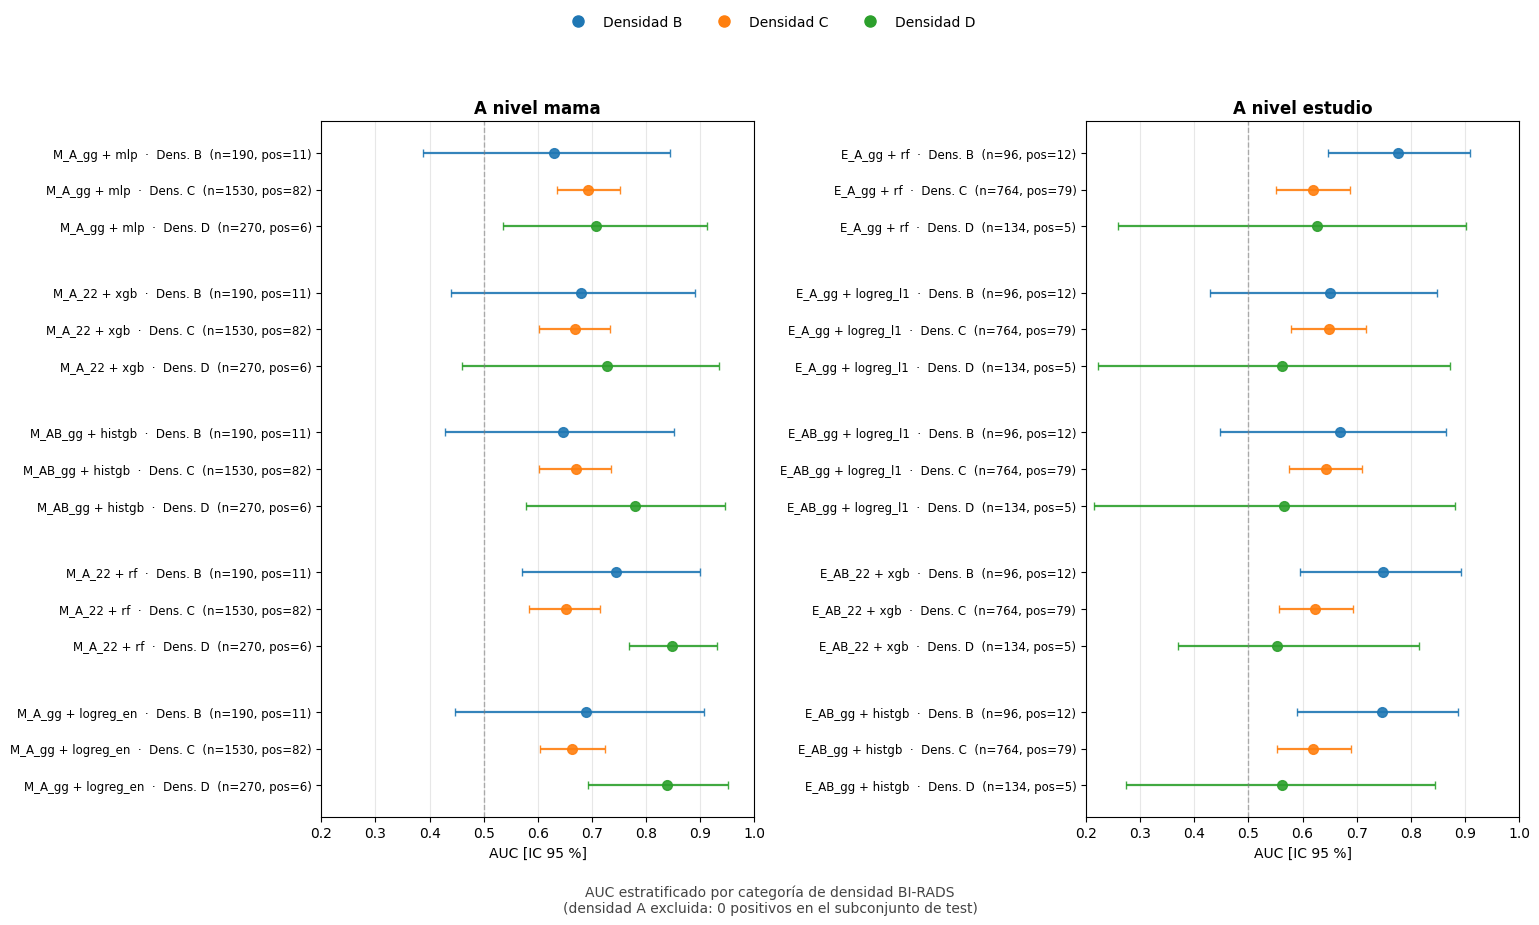

Guardado: forest_densidad.png


In [9]:
def auc_por_estrato(y_true, y_pred, densities, n_boot=1000):
    rows = []
    for d in ['A', 'B', 'C', 'D']:
        mask = densities == d
        n = int(mask.sum())
        n_pos = int(y_true[mask].sum())
        if n_pos < 2 or (n - n_pos) < 2:
            rows.append({'densidad': d, 'n': n, 'n_pos': n_pos, 'auc': np.nan, 'auc_lo': np.nan, 'auc_hi': np.nan})
            continue
        auc, lo, hi = bootstrap_metric_ci(y_true[mask], y_pred[mask], roc_auc_score, n_boot=n_boot)
        rows.append({'densidad': d, 'n': n, 'n_pos': n_pos, 'auc': auc, 'auc_lo': lo, 'auc_hi': hi})
    return pd.DataFrame(rows)

# Aplicar a las 5 mejores configuraciones por nivel
density_rows = []
top_by_level = {'mama':    df_eval[df_eval.level == 'mama'].nlargest(5, 'auc'), 'estudio': df_eval[df_eval.level == 'estudio'].nlargest(5, 'auc')}

for level, top in top_by_level.items():
    densities = density_M_test if level == 'mama' else density_E_test
    y_test = y_M_test if level == 'mama' else y_E_test
    print(f'NIVEL: {level.upper()}')
    for _, r in top.iterrows():
        _, test_pred = load_predictions(r['config'], r['head'])
        df_d = auc_por_estrato(y_test, test_pred, densities)
        df_d.insert(0, 'config', r['config']); df_d.insert(1, 'head', r['head']); df_d.insert(2, 'level', level)
        density_rows.append(df_d)
        print(f'\n  {r["config"]}__{r["head"]}  (AUC global = {r["auc"]:.4f})')
        for _, dr in df_d.iterrows():
            if not np.isnan(dr['auc']):
                print(f'{dr["densidad"]}: n={dr["n"]:4d}, pos={dr["n_pos"]:3d}, AUC={dr["auc"]:.4f} [{dr["auc_lo"]:.4f}, {dr["auc_hi"]:.4f}]')
            else:
                print(f'{dr["densidad"]}: n={dr["n"]:4d}, pos={dr["n_pos"]:3d}, AUC=NaN (n_pos insuficiente)')

df_density = pd.concat(density_rows, ignore_index=True)
df_density.to_csv(os.path.join(PRED_DIR_V2, 'eval_densidad.csv'), index=False)
print(f'\nGuardado: eval_densidad.csv')

_color_dens = {'B': '#1f77b4', 'C': '#ff7f0e', 'D': '#2ca02c'}
_dens_show = ['B', 'C', 'D']  # A se excluye (0 positivos en test)

fig, axes = plt.subplots(1, 2, figsize=(15.5, 9), sharex=True)

for ax_idx, level in enumerate(['mama', 'estudio']):
    ax = axes[ax_idx]
    df_sub = df_density[df_density.level == level]
    top = top_by_level[level]
    yticks, yticklabels, y_pos = [], [], 0

    for _, tr in top.iterrows():
        cfg, head = tr['config'], tr['head']
        for d in _dens_show:
            r_sub = df_sub[(df_sub['config']==cfg)&(df_sub['head']==head)&(df_sub['densidad']==d)]
            if len(r_sub) == 0:
                continue
            r = r_sub.iloc[0]
            if not np.isnan(r['auc']):
                ax.errorbar(r['auc'], y_pos, xerr=[[r['auc']-r['auc_lo']], [r['auc_hi']-r['auc']]], fmt='o', color=_color_dens[d], capsize=3, markersize=7, linewidth=1.6, alpha=0.9)
                label = f'{cfg} + {head}  ·  Dens. {d}  (n={r["n"]}, pos={r["n_pos"]})'
            else:
                label = f'{cfg} + {head}  ·  Dens. {d}  (n insuf.)'
            yticks.append(y_pos); yticklabels.append(label); y_pos += 1
        y_pos += 0.8

    ax.set_yticks(yticks); ax.set_yticklabels(yticklabels, fontsize=8.5)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xlim(0.2, 1.0); ax.set_xlabel('AUC [IC 95 %]')
    ax.set_title(f'A nivel {level}', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='x'); ax.invert_yaxis()

_handles = [plt.Line2D([], [], marker='o', color=c, linestyle='', markersize=8, label=f'Densidad {d}') for d, c in _color_dens.items()]
fig.legend(handles=_handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.00), frameon=False, fontsize=10)
fig.suptitle('AUC estratificado por categoría de densidad BI-RADS\n(densidad A excluida: 0 positivos en el subconjunto de test)', y=0.02, fontsize=10, color='#444')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig(os.path.join(PRED_DIR_V2, 'forest_densidad.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: forest_densidad.png')

## 6. Análisis estratificado por rango de edad

La edad de la paciente se extrae del metadato DICOM `PatientAge` en la celda de carga de metadata (Celda 3). El análisis complementa al de densidad porque la edad influye tanto en la prevalencia de hallazgos malignos como en las características tisulares que el modelo debe interpretar.

Se agrupan los estudios en cinco rangos: 20-39, 40-49, 50-59, 60-69 y 70+ años, y se calcula el AUC estratificado con IC 95 % bootstrap para cada rango.


NIVEL: MAMA - AUC por rango de edad

M_A_gg__mlp (AUC global = 0.6866)
20-39 , n= 476, pos= 14, AUC=0.5657 [0.418, 0.725]
40-49 , n= 724, pos= 31, AUC=0.7159 [0.615, 0.811]
50-59 , n= 392, pos= 18, AUC=0.5612 [0.405, 0.714]
60-69 , n= 118, pos= 12, AUC=0.5896 [0.412, 0.774]
70+   , n=  28, pos=  7, AUC=0.6803 [0.394, 0.947]

M_A_22__xgb (AUC global = 0.6813)
20-39 , n= 476, pos= 14, AUC=0.5277 [0.359, 0.700]
40-49 , n= 724, pos= 31, AUC=0.6905 [0.592, 0.779]
50-59 , n= 392, pos= 18, AUC=0.5416 [0.371, 0.706]
60-69 , n= 118, pos= 12, AUC=0.7673 [0.537, 0.936]
70+   , n=  28, pos=  7, AUC=0.8707 [0.681, 1.000]

M_AB_gg__histgb (AUC global = 0.6811)
20-39 , n= 476, pos= 14, AUC=0.6169 [0.464, 0.760]
40-49 , n= 724, pos= 31, AUC=0.6767 [0.563, 0.780]
50-59 , n= 392, pos= 18, AUC=0.5547 [0.389, 0.706]
60-69 , n= 118, pos= 12, AUC=0.6352 [0.431, 0.829]
70+   , n=  28, pos=  7, AUC=0.7891 [0.565, 1.000]

M_A_22__rf (AUC global = 0.6803)
20-39 , n= 476, pos= 14, AUC=0.5611 [0.394, 0.727]
40-4

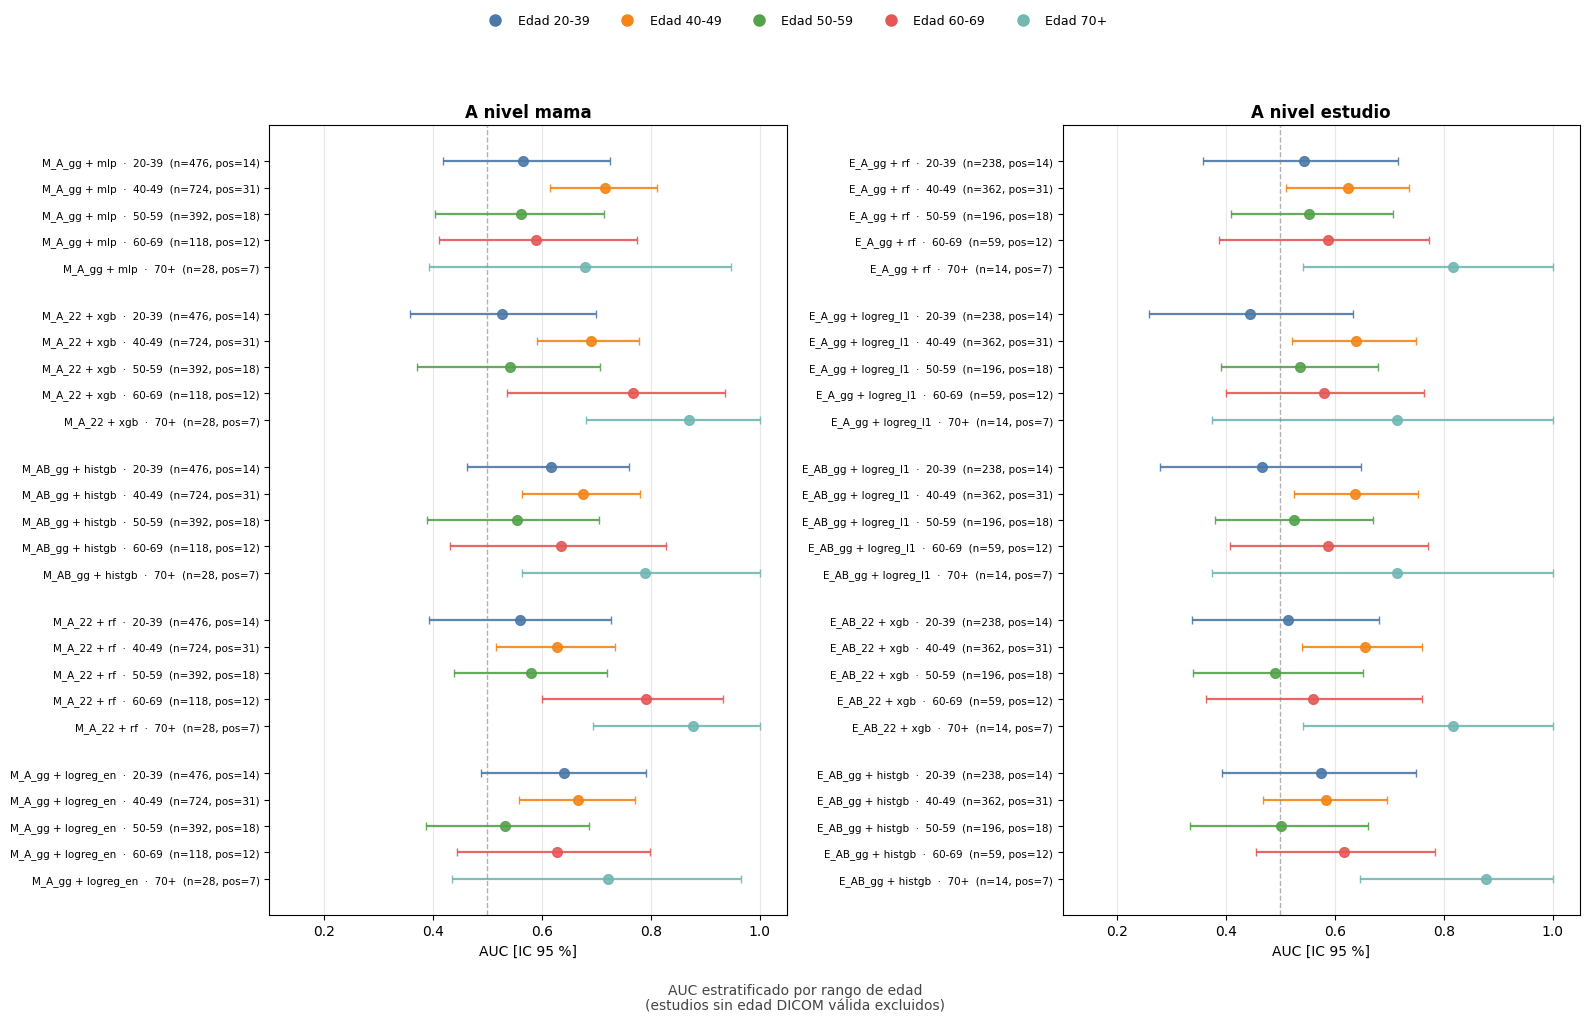

Guardado: forest_edad.png


In [10]:
if HAS_EXTRA_ANNS:
    def auc_por_edad(y_true, y_pred, age_bins, n_boot=1000):
        valid = ~pd.isna(age_bins)
        valid_arr = np.asarray(valid)
        y = y_true[valid_arr]; p = y_pred[valid_arr]
        ab = np.asarray(age_bins)[valid_arr]
        rows = []
        for b in ['20-39', '40-49', '50-59', '60-69', '70+']:
            mask = ab == b
            n = int(mask.sum())
            n_pos = int(y[mask].sum())
            if n_pos < 2 or (n - n_pos) < 2:
                rows.append({'bin': b, 'n': n, 'n_pos': n_pos, 'auc': np.nan, 'auc_lo': np.nan, 'auc_hi': np.nan})
                continue
            auc, lo, hi = bootstrap_metric_ci(y[mask], p[mask], roc_auc_score, n_boot=n_boot)
            rows.append({'bin': b, 'n': n, 'n_pos': n_pos, 'auc': auc, 'auc_lo': lo, 'auc_hi': hi})
        return pd.DataFrame(rows)

    age_rows = []
    for level, top in top_by_level.items():
        age_bins = age_bin_M_test if level == 'mama' else age_bin_E_test
        y_test = y_M_test if level == 'mama' else y_E_test
        print(f'\nNIVEL: {level.upper()} - AUC por rango de edad')
        for _, r in top.iterrows():
            _, test_pred = load_predictions(r['config'], r['head'])
            df_a = auc_por_edad(y_test, test_pred, age_bins)
            df_a.insert(0, 'config', r['config']); df_a.insert(1, 'head', r['head']); df_a.insert(2, 'level', level)
            age_rows.append(df_a)
            print(f'\n{r["config"]}__{r["head"]} (AUC global = {r["auc"]:.4f})')
            for _, dr in df_a.iterrows():
                if not np.isnan(dr['auc']):
                    print(f'{dr["bin"]:6s}, n={dr["n"]:4d}, pos={dr["n_pos"]:3d}, AUC={dr["auc"]:.4f} [{dr["auc_lo"]:.3f}, {dr["auc_hi"]:.3f}]')
                else:
                    print(f'{dr["bin"]:6s}, n={dr["n"]:4d}, pos={dr["n_pos"]:3d}, AUC=NaN (n insuf.)')

    df_edad = pd.concat(age_rows, ignore_index=True)
    df_edad.to_csv(os.path.join(PRED_DIR_V2, 'eval_edad.csv'), index=False)
    print(f'\nGuardado: eval_edad.csv')

    _color_edad = {'20-39':'#4c78a8', '40-49':'#f58518', '50-59':'#54a24b', '60-69':'#e45756', '70+':'#72b7b2'}
    _age_labels = ['20-39', '40-49', '50-59', '60-69', '70+']
    fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharex=True)

    for ax_idx, level in enumerate(['mama', 'estudio']):
        ax = axes[ax_idx]
        df_sub = df_edad[df_edad.level == level]
        top = top_by_level[level]
        yticks, yticklabels, y_pos = [], [], 0

        for _, tr in top.iterrows():
            cfg, head = tr['config'], tr['head']
            for b in _age_labels:
                r_sub = df_sub[(df_sub['config']==cfg)&(df_sub['head']==head)&(df_sub['bin']==b)]
                if len(r_sub) == 0:
                    continue
                r = r_sub.iloc[0]
                if not np.isnan(r['auc']):
                    ax.errorbar(r['auc'], y_pos, xerr=[[r['auc']-r['auc_lo']], [r['auc_hi']-r['auc']]], fmt='o', color=_color_edad[b], capsize=3, markersize=7, linewidth=1.6, alpha=0.9)
                    label = f'{cfg} + {head}  ·  {b}  (n={r["n"]}, pos={r["n_pos"]})'
                else:
                    label = f'{cfg} + {head}  ·  {b}  (n insuf.)'
                yticks.append(y_pos); yticklabels.append(label); y_pos += 1
            y_pos += 0.8

        ax.set_yticks(yticks); ax.set_yticklabels(yticklabels, fontsize=7.5)
        ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
        ax.set_xlim(0.1, 1.05); ax.set_xlabel('AUC [IC 95 %]')
        ax.set_title(f'A nivel {level}', fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3, axis='x'); ax.invert_yaxis()

    _handles = [plt.Line2D([], [], marker='o', color=c, linestyle='', markersize=8, label=f'Edad {b}')
                for b, c in _color_edad.items()]
    fig.legend(handles=_handles, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.00), frameon=False, fontsize=9)
    fig.suptitle('AUC estratificado por rango de edad\n(estudios sin edad DICOM válida excluidos)', y=0.02, fontsize=10, color='#444')
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.savefig(os.path.join(PRED_DIR_V2, 'forest_edad.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: forest_edad.png')
else:
    print('DICOM metadata no encontrado.')


## 7. Análisis de errores por categoría BI-RADS original

El clasificador binario colapsa las cinco categorías BI-RADS (1 a 5) en dos clases (no sospechoso 1-3 frente a sospechoso 4-5). Este análisis desglosa el AUC hold-out estratificándolo por categoría original y computa comparaciones pareadas entre categorías extremas (5 vs 1) y adyacentes (4 vs 3), para caracterizar dónde discrimina mejor y peor el modelo.

Los casos extremos (BI-RADS 5 frente a BI-RADS 1) son casos donde tanto el radiólogo como el modelo tienen alta confianza. Los casos adyacentes (BI-RADS 4 frente a BI-RADS 3) son la frontera de decisión clínica y la zona donde la variabilidad entre evaluadores es mayor.

Los boxplots por categoría BI-RADS del modelo final calibrado permiten ver visualmente esta distribución.


M_A_22 (estudio, calibrado): AUC global = 0.6891
M_A_gg + mlp (mama, calibrado): AUC global = 0.6866


C:\Users\victo\AppData\Local\Temp\ipykernel_4076\1255468634.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', fontsize=9)
C:\Users\victo\AppData\Local\Temp\ipykernel_4076\1255468634.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', fontsize=9)


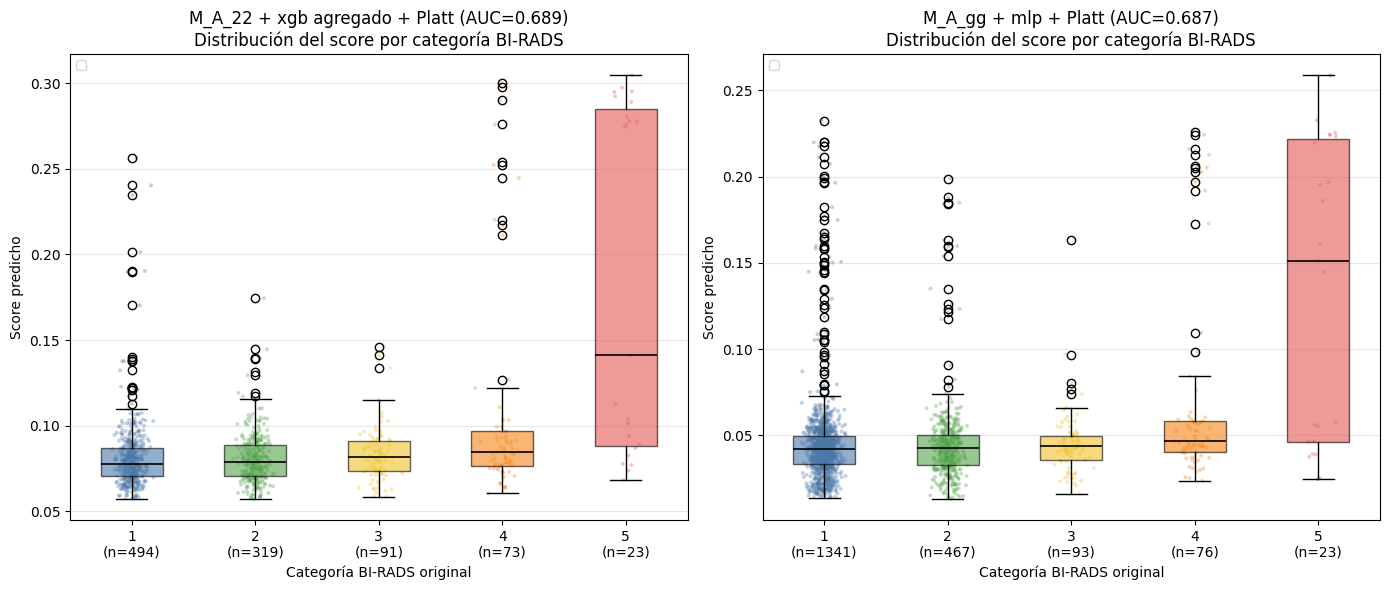

Guardado: score_por_birads.png

AUC pareado entre categorías BI-RADS (test hold-out)

M_A_22 + xgb agregado + Platt:
BI-RADS 4 vs 1: n_pos= 73, n_neg= 494, AUC=0.6518
BI-RADS 4 vs 2: n_pos= 73, n_neg= 319, AUC=0.6416
BI-RADS 4 vs 3: n_pos= 73, n_neg=  91, AUC=0.5954
BI-RADS 5 vs 1: n_pos= 23, n_neg= 494, AUC=0.8420
BI-RADS 5 vs 2: n_pos= 23, n_neg= 319, AUC=0.8359
BI-RADS 5 vs 3: n_pos= 23, n_neg=  91, AUC=0.8137

M_A_gg + mlp + Platt:
BI-RADS 4 vs 1: n_pos= 76, n_neg=1341, AUC=0.6586
BI-RADS 4 vs 2: n_pos= 76, n_neg= 467, AUC=0.6478
BI-RADS 4 vs 3: n_pos= 76, n_neg=  93, AUC=0.6269
BI-RADS 5 vs 1: n_pos= 23, n_neg=1341, AUC=0.7959
BI-RADS 5 vs 2: n_pos= 23, n_neg= 467, AUC=0.7889
BI-RADS 5 vs 3: n_pos= 23, n_neg=  93, AUC=0.7737

Guardado: auc_pairwise_birads.csv
Se espera que BI-RADS 5 vs 1 tenga AUC alto (extremos bien separados).
Se espera que BI-RADS 4 vs 3 tenga AUC más bajo (categorías adyacentes ambiguas).
Ese patrón valida clínicamente al modelo: comete errores donde también l

In [11]:
if HAS_EXTRA_ANNS:
    CALIB_DIR = os.path.join(PRED_DIR_V2, 'calibracion_predicciones')

    # M_A_22 + xgb agregado a estudio + Platt
    p_E_final = np.load(os.path.join(CALIB_DIR, 'M_A_22__xgb_agg_E__platt_test.npy'))
    assert len(p_E_final) == len(y_E_test), 'Desalineación score M_A_22 + xgb vs y_E_test'

    # M_A_gg + mlp a nivel mama + Platt
    p_M_mlp = np.load(os.path.join(CALIB_DIR, 'M_A_gg__mlp_mama__platt_test.npy'))
    assert len(p_M_mlp) == len(y_M_test), 'Desalineación score M_A_gg + mlp vs y_M_test'

    print(f'M_A_22 (estudio, calibrado): AUC global = {roc_auc_score(y_E_test, p_E_final):.4f}')
    print(f'M_A_gg + mlp (mama, calibrado): AUC global = {roc_auc_score(y_M_test, p_M_mlp):.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    _cats = [1, 2, 3, 4, 5]
    _colors_bp = ['#4c78a8', '#54a24b', '#f0c22a', '#f58518', '#e45756']
    _rng = np.random.default_rng(SEED)

    for ax, (score, birads_orig, title, auc_ref) in zip(axes, [
        (p_E_final, birads_E_orig_test, 'M_A_22 + xgb agregado + Platt', 0.689),
        (p_M_mlp,   birads_M_orig_test, 'M_A_gg + mlp + Platt', 0.687),
    ]):
        data_by_cat = [score[birads_orig == b] for b in _cats]
        bp = ax.boxplot(data_by_cat, positions=_cats, widths=0.5, patch_artist=True, medianprops=dict(color='black', linewidth=1.2))
        for patch, c in zip(bp['boxes'], _colors_bp):
            patch.set_facecolor(c); patch.set_alpha(0.6)
        for i, b in enumerate(_cats):
            data = score[birads_orig == b]
            x_jitter = _rng.normal(loc=b, scale=0.06, size=len(data))
            ax.scatter(x_jitter, data, s=8, alpha=0.35, color=_colors_bp[i], edgecolors='none')
        ax.set_xlabel('Categoría BI-RADS original')
        ax.set_ylabel('Score predicho')
        ax.set_title(f'{title} (AUC={auc_ref:.3f})\nDistribución del score por categoría BI-RADS')
        ax.set_xticks(_cats)
        ax.set_xticklabels([f'{b}\n(n={(birads_orig==b).sum()})' for b in _cats])
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(os.path.join(PRED_DIR_V2, 'score_por_birads.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: score_por_birads.png')

    def _pairwise_auc(scores_pos, scores_neg):
        if len(scores_pos) < 2 or len(scores_neg) < 2:
            return np.nan
        y_pair = np.concatenate([np.ones(len(scores_pos)), np.zeros(len(scores_neg))])
        s_pair = np.concatenate([scores_pos, scores_neg])
        return roc_auc_score(y_pair, s_pair)

    pw_rows = []
    for nombre, score, birads_orig in [
        ('M_A_22 + xgb agregado + Platt', p_E_final, birads_E_orig_test),
        ('M_A_gg + mlp + Platt', p_M_mlp, birads_M_orig_test),
    ]:
        for pos_b in [4, 5]:
            for neg_b in [1, 2, 3]:
                pos = score[birads_orig == pos_b]
                neg = score[birads_orig == neg_b]
                a = _pairwise_auc(pos, neg)
                pw_rows.append({'modelo': nombre, 'pos_birads': pos_b, 'neg_birads': neg_b, 'n_pos': len(pos), 'n_neg': len(neg), 'auc_pairwise': a})

    df_pw = pd.DataFrame(pw_rows)
    print('\nAUC pareado entre categorías BI-RADS (test hold-out)')
    for nombre in df_pw['modelo'].unique():
        print(f'\n{nombre}:')
        sub = df_pw[df_pw['modelo'] == nombre]
        for _, r in sub.iterrows():
            print(f'BI-RADS {r["pos_birads"]} vs {r["neg_birads"]}: n_pos={r["n_pos"]:3d}, n_neg={r["n_neg"]:4d}, AUC={r["auc_pairwise"]:.4f}')

    df_pw.to_csv(os.path.join(PRED_DIR_V2, 'auc_pairwise_birads.csv'), index=False)
    print('\nGuardado: auc_pairwise_birads.csv')

    print('Se espera que BI-RADS 5 vs 1 tenga AUC alto (extremos bien separados).')
    print('Se espera que BI-RADS 4 vs 3 tenga AUC más bajo (categorías adyacentes ambiguas).')
    print('Ese patrón valida clínicamente al modelo: comete errores donde también los cometería el radiólogo.')
else:
    print('DICOM metadata no encontrado.')


## 8. Análisis por subgrupos del modelo final calibrado
Los análisis anteriores se calculan sobre los scores crudos de las 84 ejecuciones del pipeline. En esta subsección se repiten específicamente sobre los dos modelos finales calibrados con Platt scaling que produce NB12:

- `M_A_22 + xgb` agregado a estudio, calibrado con Platt.
- `M_A_gg + mlp`, calibrado con Platt.

Sobre estos dos modelos se produce una figura que superpone ambos por categoría de densidad y por rango de edad, con IC 95 % bootstrap.

In [12]:
# Cargar scores calibrados de los dos modelos finales (producidos por NB12)
CALIB_DIR = os.path.join(PRED_DIR_V2, 'calibracion_predicciones')

# M_A_22 + xgb agregado + Platt
score_final_E = np.load(os.path.join(CALIB_DIR, 'M_A_22__xgb_agg_E__platt_test.npy'))
assert len(score_final_E) == len(y_E_test), 'Desalineación score M_A_22 + xgb vs y_E_test'

# M_A_gg + mlp + Platt
score_final_M = np.load(os.path.join(CALIB_DIR, 'M_A_gg__mlp_mama__platt_test.npy'))
assert len(score_final_M) == len(y_M_test), 'Desalineación score M_A_gg + mlp vs y_M_test'

print(f'M_A_22 + xgb agregado + Platt (nivel estudio): n={len(score_final_E):4d}, AUC global = {roc_auc_score(y_E_test, score_final_E):.4f}')
print(f'M_A_gg + mlp + Platt (nivel mama): n={len(score_final_M):4d}, AUC global = {roc_auc_score(y_M_test, score_final_M):.4f}')

M_A_22 + xgb agregado + Platt (nivel estudio): n=1000, AUC global = 0.6891
M_A_gg + mlp + Platt (nivel mama): n=2000, AUC global = 0.6866


In [13]:


# M_A_22 + xgb agregado + Platt
df_E_density = auc_por_estrato(y_E_test, score_final_E, density_E_test, n_boot=1000)
df_E_density.insert(0, 'level',  'estudio')
df_E_density.insert(1, 'modelo', 'M_A_22 + xgb (agregado + Platt)')
print('M_A_22 + xgb (agregado + Platt) - AUC por densidad')
for _, r in df_E_density.iterrows():
    if not np.isnan(r['auc']):
        print(f'Dens. {r["densidad"]}: n={r["n"]:4d}, pos={r["n_pos"]:3d}, AUC={r["auc"]:.4f} [{r["auc_lo"]:.3f}, {r["auc_hi"]:.3f}]')
    else:
        print(f'Dens. {r["densidad"]}: n={r["n"]:4d}, pos={r["n_pos"]:3d}, AUC=NaN (n insuficiente)')

# M_A_gg + mlp + Platt
df_M_density = auc_por_estrato(y_M_test, score_final_M, density_M_test, n_boot=1000)
df_M_density.insert(0, 'level',  'mama')
df_M_density.insert(1, 'modelo', 'M_A_gg + mlp (Platt)')
print('\nM_A_gg + mlp (Platt) - AUC por densidad')
for _, r in df_M_density.iterrows():
    if not np.isnan(r['auc']):
        print(f'Dens. {r["densidad"]}: n={r["n"]:4d}, pos={r["n_pos"]:3d}, AUC={r["auc"]:.4f} [{r["auc_lo"]:.3f}, {r["auc_hi"]:.3f}]')
    else:
        print(f'Dens. {r["densidad"]}: n={r["n"]:4d}, pos={r["n_pos"]:3d}, AUC=NaN (n insuficiente)')

df_density_final = pd.concat([df_E_density, df_M_density], ignore_index=True)
df_density_final.to_csv(os.path.join(PRED_DIR_V2, 'eval_densidad_modelo_final.csv'), index=False)
print(f'\nGuardado: eval_densidad_modelo_final.csv')

M_A_22 + xgb (agregado + Platt) - AUC por densidad
Dens. A: n=   6, pos=  0, AUC=NaN (n insuficiente)
Dens. B: n=  96, pos= 12, AUC=0.7649 [0.612, 0.899]
Dens. C: n= 764, pos= 79, AUC=0.6638 [0.591, 0.729]
Dens. D: n= 134, pos=  5, AUC=0.6977 [0.392, 0.998]

M_A_gg + mlp (Platt) - AUC por densidad
Dens. A: n=  10, pos=  0, AUC=NaN (n insuficiente)
Dens. B: n= 190, pos= 11, AUC=0.6298 [0.388, 0.845]
Dens. C: n=1530, pos= 82, AUC=0.6926 [0.636, 0.751]
Dens. D: n= 270, pos=  6, AUC=0.7071 [0.536, 0.912]

Guardado: eval_densidad_modelo_final.csv


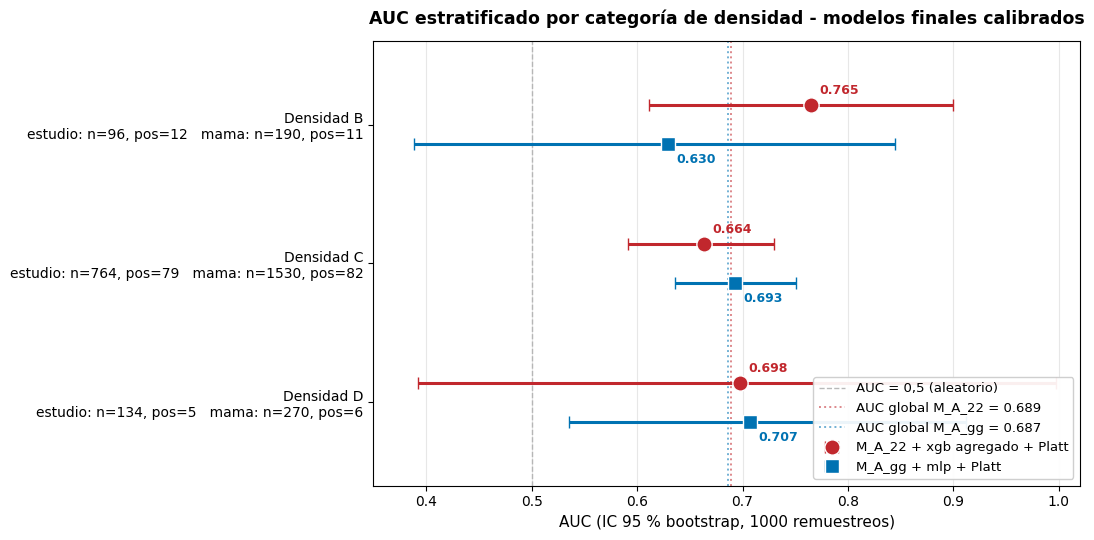

Guardado: auc_densidad_modelo_final.png


In [14]:
_dens_show = ['B', 'C', 'D']

# AUC globales
auc_global_E = roc_auc_score(y_E_test, score_final_E)
auc_global_M = roc_auc_score(y_M_test, score_final_M)

fig, ax = plt.subplots(figsize=(11, 5.5))

# Offset vertical para que los IC de ambos modelos no se solapen
OFFSET = 0.14

# M_A_22 + xgb agregado + Platt
for i, d in enumerate(_dens_show):
    r = df_E_density[df_E_density['densidad'] == d].iloc[0]
    if np.isnan(r['auc']):
        continue
    ax.errorbar(r['auc'], i - OFFSET,
                xerr=[[r['auc']-r['auc_lo']], [r['auc_hi']-r['auc']]],
                fmt='o', color='#c1272d', capsize=4, markersize=11, linewidth=2.2,
                label='M_A_22 + xgb agregado + Platt' if i == 0 else None,
                markeredgecolor='white', markeredgewidth=1.0, zorder=3)
    # Anotación con AUC
    ax.annotate(f'{r["auc"]:.3f}', xy=(r['auc'], i - OFFSET),
                xytext=(6, 8), textcoords='offset points',
                fontsize=9, color='#c1272d', fontweight='bold')

# M_A_gg + mlp + Platt
for i, d in enumerate(_dens_show):
    r = df_M_density[df_M_density['densidad'] == d].iloc[0]
    if np.isnan(r['auc']):
        continue
    ax.errorbar(r['auc'], i + OFFSET,
                xerr=[[r['auc']-r['auc_lo']], [r['auc_hi']-r['auc']]],
                fmt='s', color='#0072b2', capsize=4, markersize=10, linewidth=2.2,
                label='M_A_gg + mlp + Platt' if i == 0 else None,
                markeredgecolor='white', markeredgewidth=1.0, zorder=3)
    ax.annotate(f'{r["auc"]:.3f}', xy=(r['auc'], i + OFFSET),
                xytext=(6, -14), textcoords='offset points',
                fontsize=9, color='#0072b2', fontweight='bold')

# Líneas de referencia
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.55, zorder=1,
           label='AUC = 0,5 (aleatorio)')
ax.axvline(auc_global_E, color='#c1272d', linestyle=':', linewidth=1.4, alpha=0.55, zorder=1,
           label=f'AUC global M_A_22 = {auc_global_E:.3f}')
ax.axvline(auc_global_M, color='#0072b2', linestyle=':', linewidth=1.4, alpha=0.55, zorder=1,
           label=f'AUC global M_A_gg = {auc_global_M:.3f}')

# Etiquetas del eje Y con n y positivos por densidad
yticklabels = []
for d in _dens_show:
    rE = df_E_density[df_E_density['densidad'] == d].iloc[0]
    rM = df_M_density[df_M_density['densidad'] == d].iloc[0]
    lbl = (f'Densidad {d}\n'
           f'estudio: n={int(rE["n"])}, pos={int(rE["n_pos"])}   '
           f'mama: n={int(rM["n"])}, pos={int(rM["n_pos"])}')
    yticklabels.append(lbl)
ax.set_yticks(range(len(_dens_show)))
ax.set_yticklabels(yticklabels, fontsize=10)

ax.set_xlabel('AUC (IC 95 % bootstrap, 1000 remuestreos)', fontsize=11)
ax.set_title('AUC estratificado por categoría de densidad - modelos finales calibrados', fontsize=12.5, fontweight='bold', pad=12)
ax.set_xlim(0.35, 1.02)
ax.set_ylim(-0.6, len(_dens_show) - 0.4)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
ax.legend(loc='lower right', fontsize=9.5, framealpha=0.93, ncol=1)

plt.tight_layout()
plt.savefig(os.path.join(PRED_DIR_V2, 'auc_densidad_modelo_final.png'), dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Guardado: auc_densidad_modelo_final.png')

In [15]:
# M_A_22 + xgb agregado + Platt
df_E_edad = auc_por_edad(y_E_test, score_final_E, age_bin_E_test, n_boot=1000)
df_E_edad.insert(0, 'level',  'estudio')
df_E_edad.insert(1, 'modelo', 'M_A_22 + xgb (agregado + Platt)')
print('M_A_22 + xgb (agregado + Platt) - AUC por rango de edad')
for _, r in df_E_edad.iterrows():
    if not np.isnan(r['auc']):
        print(f'{r["bin"]:6s}, n={r["n"]:4d}, pos={r["n_pos"]:3d}, AUC={r["auc"]:.4f} [{r["auc_lo"]:.3f}, {r["auc_hi"]:.3f}]')
    else:
        print(f'{r["bin"]:6s}, n={r["n"]:4d}, pos={r["n_pos"]:3d}, AUC=NaN (n insuf.)')

# M_A_gg + mlp + Platt
df_M_edad = auc_por_edad(y_M_test, score_final_M, age_bin_M_test, n_boot=1000)
df_M_edad.insert(0, 'level',  'mama')
df_M_edad.insert(1, 'modelo', 'M_A_gg + mlp (Platt)')
print('\nM_A_gg + mlp (Platt) - AUC por rango de edad')
for _, r in df_M_edad.iterrows():
    if not np.isnan(r['auc']):
        print(f'{r["bin"]:6s}, n={r["n"]:4d}, pos={r["n_pos"]:3d}, AUC={r["auc"]:.4f} [{r["auc_lo"]:.3f}, {r["auc_hi"]:.3f}]')
    else:
        print(f'{r["bin"]:6s}, n={r["n"]:4d}, pos={r["n_pos"]:3d}, AUC=NaN (n insuf.)')

df_edad_final = pd.concat([df_E_edad, df_M_edad], ignore_index=True)
df_edad_final.to_csv(os.path.join(PRED_DIR_V2, 'eval_edad_modelo_final.csv'), index=False)
print(f'\nGuardado: eval_edad_modelo_final.csv')

M_A_22 + xgb (agregado + Platt) - AUC por rango de edad
20-39 , n= 238, pos= 14, AUC=0.5922 [0.413, 0.762]
40-49 , n= 362, pos= 31, AUC=0.6545 [0.549, 0.753]
50-59 , n= 196, pos= 18, AUC=0.6451 [0.507, 0.781]
60-69 , n=  59, pos= 12, AUC=0.8050 [0.661, 0.936]
70+   , n=  14, pos=  7, AUC=0.9184 [0.729, 1.000]

M_A_gg + mlp (Platt) - AUC por rango de edad
20-39 , n= 476, pos= 14, AUC=0.5657 [0.418, 0.725]
40-49 , n= 724, pos= 31, AUC=0.7159 [0.615, 0.811]
50-59 , n= 392, pos= 18, AUC=0.5612 [0.405, 0.714]
60-69 , n= 118, pos= 12, AUC=0.5896 [0.412, 0.774]
70+   , n=  28, pos=  7, AUC=0.6803 [0.394, 0.947]

Guardado: eval_edad_modelo_final.csv


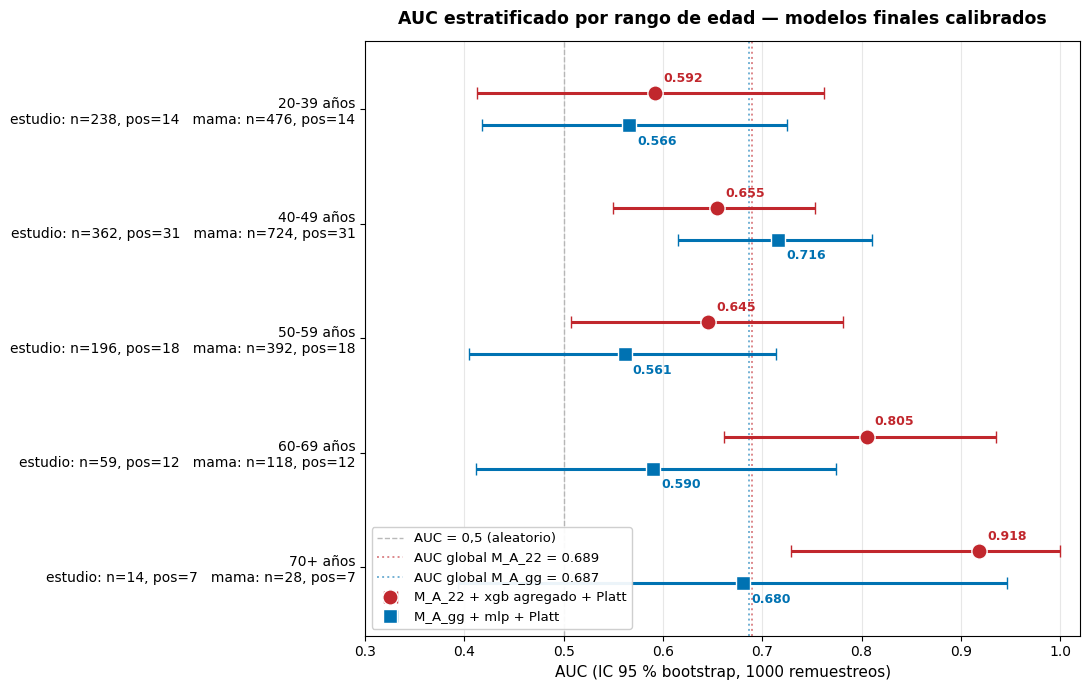

Guardado: auc_edad_modelo_final.png


In [16]:
_age_labels = ['20-39', '40-49', '50-59', '60-69', '70+']

# AUC globales
auc_global_E = roc_auc_score(y_E_test, score_final_E)
auc_global_M = roc_auc_score(y_M_test, score_final_M)

fig, ax = plt.subplots(figsize=(11, 7))

OFFSET = 0.14

# M_A_22 + xgb agregado + Platt — círculo rojo
for i, b in enumerate(_age_labels):
    r = df_E_edad[df_E_edad['bin'] == b].iloc[0]
    if np.isnan(r['auc']):
        ax.text(0.5, i - OFFSET, 'n insuficiente', fontsize=9, color='#c1272d', ha='center', va='center')
        continue
    ax.errorbar(r['auc'], i - OFFSET,
                xerr=[[r['auc']-r['auc_lo']], [r['auc_hi']-r['auc']]],
                fmt='o', color='#c1272d', capsize=4, markersize=11, linewidth=2.2,
                label='M_A_22 + xgb agregado + Platt' if i == 0 else None,
                markeredgecolor='white', markeredgewidth=1.0, zorder=3)
    ax.annotate(f'{r["auc"]:.3f}', xy=(r['auc'], i - OFFSET),
                xytext=(6, 8), textcoords='offset points',
                fontsize=9, color='#c1272d', fontweight='bold')

# M_A_gg + mlp + Platt — cuadrado azul
for i, b in enumerate(_age_labels):
    r = df_M_edad[df_M_edad['bin'] == b].iloc[0]
    if np.isnan(r['auc']):
        ax.text(0.5, i + OFFSET, 'n insuficiente', fontsize=9, color='#0072b2', ha='center', va='center')
        continue
    ax.errorbar(r['auc'], i + OFFSET,
                xerr=[[r['auc']-r['auc_lo']], [r['auc_hi']-r['auc']]],
                fmt='s', color='#0072b2', capsize=4, markersize=10, linewidth=2.2,
                label='M_A_gg + mlp + Platt' if i == 0 else None,
                markeredgecolor='white', markeredgewidth=1.0, zorder=3)
    ax.annotate(f'{r["auc"]:.3f}', xy=(r['auc'], i + OFFSET),
                xytext=(6, -14), textcoords='offset points',
                fontsize=9, color='#0072b2', fontweight='bold')

# Líneas de referencia
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.55, zorder=1,
           label='AUC = 0,5 (aleatorio)')
ax.axvline(auc_global_E, color='#c1272d', linestyle=':', linewidth=1.4, alpha=0.55, zorder=1,
           label=f'AUC global M_A_22 = {auc_global_E:.3f}')
ax.axvline(auc_global_M, color='#0072b2', linestyle=':', linewidth=1.4, alpha=0.55, zorder=1,
           label=f'AUC global M_A_gg = {auc_global_M:.3f}')

# Etiquetas del eje Y con n y positivos por rango de edad
yticklabels = []
for b in _age_labels:
    rE = df_E_edad[df_E_edad['bin'] == b].iloc[0]
    rM = df_M_edad[df_M_edad['bin'] == b].iloc[0]
    lbl = (f'{b} años\n'
           f'estudio: n={int(rE["n"])}, pos={int(rE["n_pos"])}   '
           f'mama: n={int(rM["n"])}, pos={int(rM["n_pos"])}')
    yticklabels.append(lbl)
ax.set_yticks(range(len(_age_labels)))
ax.set_yticklabels(yticklabels, fontsize=10)

ax.set_xlabel('AUC (IC 95 % bootstrap, 1000 remuestreos)', fontsize=11)
ax.set_title('AUC estratificado por rango de edad — modelos finales calibrados',
             fontsize=12.5, fontweight='bold', pad=12)
ax.set_xlim(0.30, 1.02)
ax.set_ylim(-0.6, len(_age_labels) - 0.4)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
ax.legend(loc='lower left', fontsize=9.5, framealpha=0.93, ncol=1)

plt.tight_layout()
plt.savefig(os.path.join(PRED_DIR_V2, 'auc_edad_modelo_final.png'),
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Guardado: auc_edad_modelo_final.png')

## 9. Matrices de confusión de los modelos finales calibrados

Complemento visual del análisis anterior con matrices de confusión sobre el hold-out. Los scores calibrados por Platt están comprimidos cerca de la prevalencia real (aprox. 9,6 % nivel estudio, 4,95 % nivel mama), por lo que el umbral tradicional 0,5 no es clínicamente útil (clasificaría casi todo como no sospechoso).

Se evalúan dos puntos operativos por modelo:

- **Youden index**: umbral que maximiza sensibilidad + especificidad - 1.
- **Sensibilidad ≥ 0.75**: umbral que garantiza captura de al menos el 75 % de los casos positivos.

Los umbrales se derivan sobre las predicciones out-of-fold (calibradas con Platt) y se aplican al hold-out. Este procedimiento evita el sesgo de seleccionar el umbral sobre el mismo conjunto en el que se evalúa.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

def platt_calibrate_local(p_source, y_source, p_target):
    clf = LogisticRegression(C=1e8, solver='lbfgs', max_iter=1000)
    clf.fit(p_source.reshape(-1, 1), y_source)
    return clf.predict_proba(p_target.reshape(-1, 1))[:, 1]

def youden_threshold(y_true, y_score):
    fpr, tpr, thr = roc_curve(y_true, y_score)
    j = tpr - fpr
    ix = int(np.argmax(j))
    return float(thr[ix]), float(tpr[ix]), float(1.0 - fpr[ix]), float(j[ix])

def sens_threshold(y_true, y_score, target_sens=0.75):
    fpr, tpr, thr = roc_curve(y_true, y_score)
    valid = tpr >= target_sens
    if not valid.any():
        return None, None, None
    valid_thr = thr[valid]
    valid_fpr = fpr[valid]
    valid_tpr = tpr[valid]
    ix = int(np.argmin(valid_fpr))
    return float(valid_thr[ix]), float(valid_tpr[ix]), float(1.0 - valid_fpr[ix])

# M_A_22 + xgb. El modelo se entrena a nivel mama pero se aplica a estudio agregando con max(L,R)
p_oof_M_xgb, _ = load_predictions('M_A_22', 'xgb')
p_L_oof = p_oof_M_xgb[:len(y_E_oof)]
p_R_oof = p_oof_M_xgb[len(y_E_oof):]
p_oof_E_agg = np.maximum(p_L_oof, p_R_oof)

# Calibrar Platt sobre OOF agregadas
p_oof_E_platt = platt_calibrate_local(p_oof_E_agg, y_E_oof, p_oof_E_agg)

# Determinar umbrales sobre OOF calibradas
t_youden_E, sens_oof_y_E, spec_oof_y_E, j_E = youden_threshold(y_E_oof, p_oof_E_platt)
t_sens_E, sens_oof_s_E, spec_oof_s_E = sens_threshold(y_E_oof, p_oof_E_platt, 0.75)

print('M_A_22 + xgb (nivel estudio)')
print(f'Umbral Youden: t = {t_youden_E:.4f} (OOF: sens={sens_oof_y_E:.3f}, spec={spec_oof_y_E:.3f}, J={j_E:.3f})')
print(f'Umbral sens ≥ 0,75: t = {t_sens_E:.4f} (OOF: sens={sens_oof_s_E:.3f}, spec={spec_oof_s_E:.3f})')

# M_A_gg + mlp a nivel mama
p_oof_M_mlp, _ = load_predictions('M_A_gg', 'mlp')
p_oof_M_platt = platt_calibrate_local(p_oof_M_mlp, y_M_oof, p_oof_M_mlp)

t_youden_M, sens_oof_y_M, spec_oof_y_M, j_M = youden_threshold(y_M_oof, p_oof_M_platt)
t_sens_M, sens_oof_s_M, spec_oof_s_M = sens_threshold(y_M_oof, p_oof_M_platt, 0.75)

print('\nM_A_gg + mlp (nivel mama)')
print(f'  Umbral Youden: t = {t_youden_M:.4f} (OOF: sens={sens_oof_y_M:.3f}, spec={spec_oof_y_M:.3f}, J={j_M:.3f})')
print(f'  Umbral sens ≥ 0,75: t = {t_sens_M:.4f} (OOF: sens={sens_oof_s_M:.3f}, spec={spec_oof_s_M:.3f})')

M_A_22 + xgb (nivel estudio)
Umbral Youden: t = 0.1273 (OOF: sens=0.351, spec=0.879, J=0.229)
Umbral sens ≥ 0,75: t = 0.0804 (OOF: sens=0.751, spec=0.310)

M_A_gg + mlp (nivel mama)
  Umbral Youden: t = 0.0469 (OOF: sens=0.585, spec=0.633, J=0.217)
  Umbral sens ≥ 0,75: t = 0.0399 (OOF: sens=0.752, spec=0.405)


In [18]:
def compute_cm_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    f1 = 2 * ppv * sens / (ppv + sens) if (ppv + sens) > 0 else 0.0
    return {
        'cm': cm, 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'sens': sens, 'spec': spec, 'ppv': ppv, 'npv': npv, 'f1': f1,
    }

resultados = {}

# M_A_22 + xgb - Youden
resultados['triaje_youden'] = {
    'modelo': 'M_A_22 + xgb agregado + Platt', 'nivel': 'estudio',
    'umbral_tipo': 'Youden index', 'umbral': t_youden_E,
    **compute_cm_metrics(y_E_test, (score_final_E >= t_youden_E).astype(int)),
}
# M_A_22 + xgb - sens 0,75
resultados['triaje_sens85'] = {
    'modelo': 'M_A_22 + xgb agregado + Platt', 'nivel': 'estudio',
    'umbral_tipo': 'Sensibilidad ≥ 0,75', 'umbral': t_sens_E,
    **compute_cm_metrics(y_E_test, (score_final_E >= t_sens_E).astype(int)),
}
# M_A_gg + mlp - Youden
resultados['loc_youden'] = {
    'modelo': 'M_A_gg + mlp + Platt', 'nivel': 'mama',
    'umbral_tipo': 'Youden index', 'umbral': t_youden_M,
    **compute_cm_metrics(y_M_test, (score_final_M >= t_youden_M).astype(int)),
}
# M_A_gg + mlp - sens 0,75
resultados['loc_sens85'] = {
    'modelo': 'M_A_gg + mlp + Platt', 'nivel': 'mama',
    'umbral_tipo': 'Sensibilidad ≥ 0,75', 'umbral': t_sens_M,
    **compute_cm_metrics(y_M_test, (score_final_M >= t_sens_M).astype(int)),
}

# Imprimir tabla resumen
print(f'\n{"-"*120}')
print(f'{"Modelo / Umbral":<52s}  {"TP":>4s} {"FP":>4s} {"FN":>4s} {"TN":>5s}  {"Sens":>6s} {"Spec":>6s} {"VPP":>6s} {"VPN":>6s} {"F1":>6s}')
print(f'{"-"*120}')
for key, r in resultados.items():
    modelo_corto = 'Triaje' if 'triaje' in key else 'Localización'
    label = f'{modelo_corto:<14s}  {r["umbral_tipo"]:<22s} (t={r["umbral"]:.4f})'
    print(f'{label:<52s}  {r["tp"]:>4d} {r["fp"]:>4d} {r["fn"]:>4d} {r["tn"]:>5d}  '
          f'{r["sens"]:>6.3f} {r["spec"]:>6.3f} {r["ppv"]:>6.3f} {r["npv"]:>6.3f} {r["f1"]:>6.3f}')
print(f'{"-"*120}')

# Guardar CSV
df_cm = pd.DataFrame([
    {'modelo': r['modelo'], 'nivel': r['nivel'], 'umbral_tipo': r['umbral_tipo'], 'umbral': r['umbral'],
     'TP': r['tp'], 'FP': r['fp'], 'FN': r['fn'], 'TN': r['tn'],
     'sens': r['sens'], 'spec': r['spec'], 'ppv': r['ppv'], 'npv': r['npv'], 'f1': r['f1']}
    for r in resultados.values()
])
df_cm.to_csv(os.path.join(PRED_DIR_V2, 'matrices_confusion_modelo_final.csv'), index=False)
print(f'\nGuardado: matrices_confusion_modelo_final.csv')


------------------------------------------------------------------------------------------------------------------------
Modelo / Umbral                                         TP   FP   FN    TN    Sens   Spec    VPP    VPN     F1
------------------------------------------------------------------------------------------------------------------------
Triaje          Youden index           (t=0.1273)       22   21   74   883   0.229  0.977  0.512  0.923  0.317
Triaje          Sensibilidad ≥ 0,75    (t=0.0804)       64  402   32   502   0.667  0.555  0.137  0.940  0.228
Localización    Youden index           (t=0.0469)       54  635   45  1266   0.545  0.666  0.078  0.966  0.137
Localización    Sensibilidad ≥ 0,75    (t=0.0399)       77 1090   22   811   0.778  0.427  0.066  0.974  0.122
------------------------------------------------------------------------------------------------------------------------

Guardado: matrices_confusion_modelo_final.csv


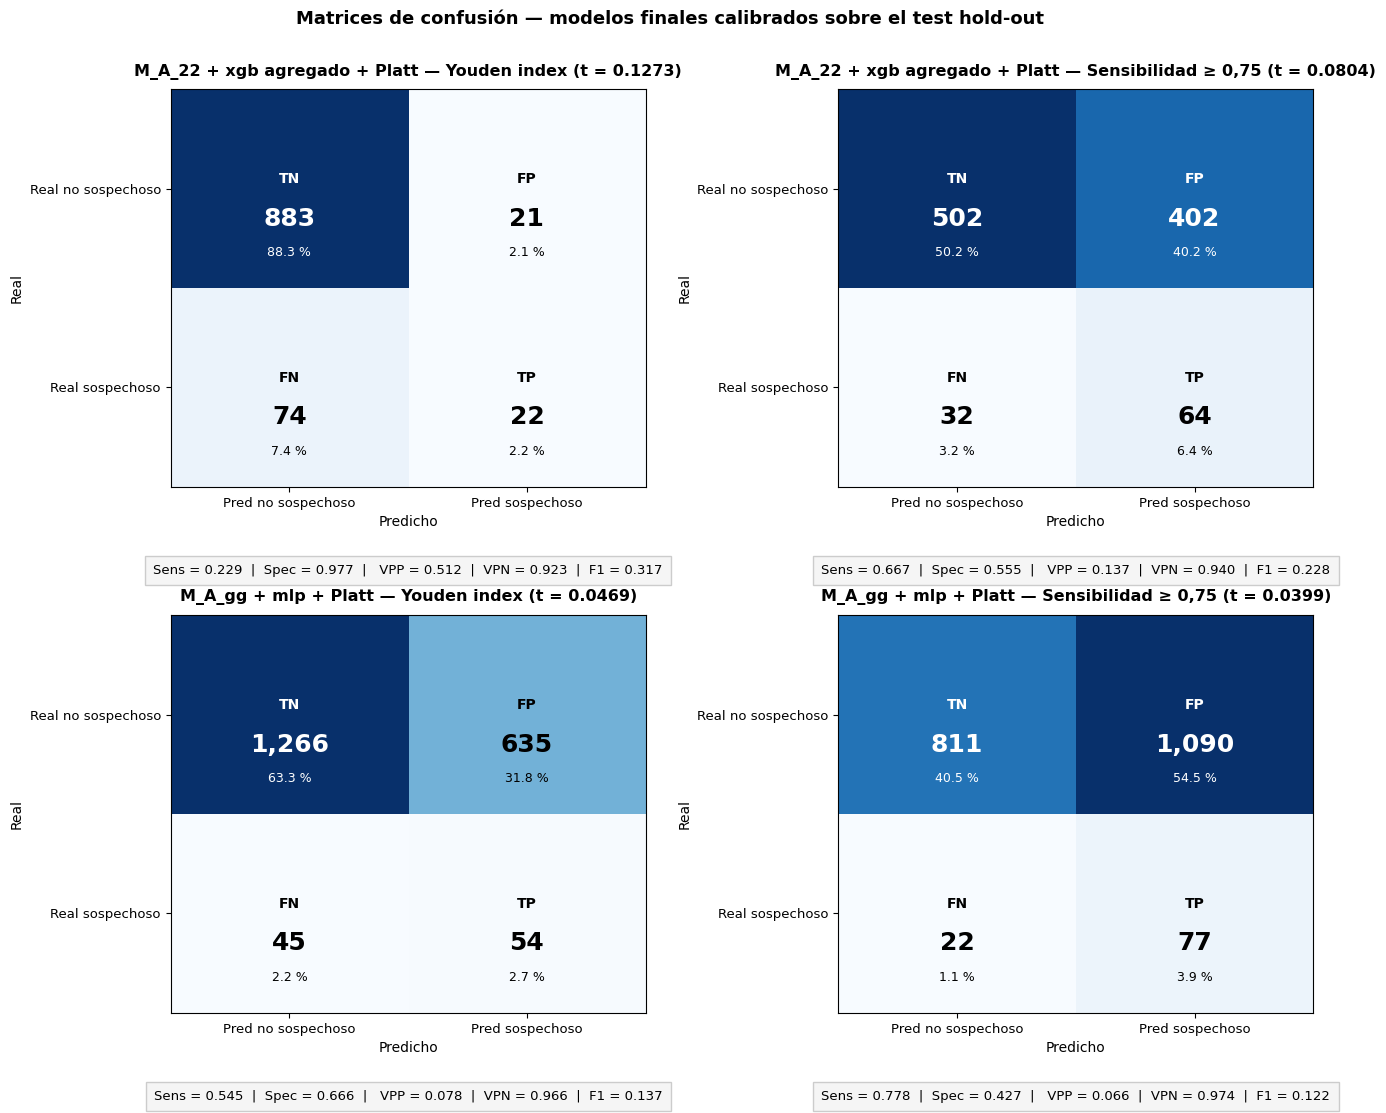

Guardado: matrices_confusion_modelo_final.png


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 11))
orden = [
    ('triaje_youden', axes[0][0]),
    ('triaje_sens85', axes[0][1]),
    ('loc_youden', axes[1][0]),
    ('loc_sens85', axes[1][1]),
]

for key, ax in orden:
    r = resultados[key]
    cm = r['cm']
    modelo_corto = 'M_A_22 + xgb agregado + Platt' if 'triaje' in key else 'M_A_gg + mlp + Platt'
    n_total = cm.sum()

    im = ax.imshow(cm, cmap='Blues', aspect='auto', interpolation='nearest')

    # Anotaciones dentro de cada celda
    labels_matriz = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            v = cm[i, j]
            pct = 100 * v / n_total if n_total > 0 else 0
            color = 'white' if v > cm.max() * 0.55 else 'black'
            ax.text(j, i - 0.05, labels_matriz[i][j], ha='center', va='center', fontsize=10, color=color, fontweight='bold')
            ax.text(j, i + 0.15, f'{v:,}', ha='center', va='center', fontsize=18, color=color, fontweight='bold')
            ax.text(j, i + 0.32, f'{pct:.1f} %', ha='center', va='center', fontsize=9, color=color)

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred no sospechoso', 'Pred sospechoso'], fontsize=9.5)
    ax.set_yticklabels(['Real no sospechoso', 'Real sospechoso'], fontsize=9.5)
    ax.set_ylabel('Real', fontsize=10)
    ax.set_xlabel('Predicho', fontsize=10)

    # Título
    ax.set_title(f'{modelo_corto} — {r["umbral_tipo"]} (t = {r["umbral"]:.4f})', fontsize=11.5, fontweight='bold', pad=10)

    # Subtítulo con métricas
    metricas_txt = (f'Sens = {r["sens"]:.3f}  |  Spec = {r["spec"]:.3f}  |   VPP = {r["ppv"]:.3f}  |  VPN = {r["npv"]:.3f}  |  F1 = {r["f1"]:.3f}')
    ax.text(0.5, -0.22, metricas_txt, transform=ax.transAxes, ha='center', fontsize=9.5, bbox=dict(facecolor='#f5f5f5', edgecolor='#cccccc', pad=6))

fig.suptitle('Matrices de confusión — modelos finales calibrados sobre el test hold-out', fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(PRED_DIR_V2, 'matrices_confusion_modelo_final.png'), dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Guardado: matrices_confusion_modelo_final.png')

## 10. Análisis post-hoc: agregación de mama a estudio

Para cada modelo a nivel mama se calcula la predicción a nivel estudio agregando por máximo entre las dos mamas. Permite comparar dos estrategias para obtener una predicción a nivel estudio: entrenar directamente a nivel estudio, o entrenar a nivel mama y agregar posteriormente.

In [20]:
post_hoc_rows = []
for _, r in df_eval[df_eval.level == 'mama'].iterrows():
    cfg_m, head, auc_m = r['config'], r['head'], r['auc']
    # Cargar predicciones a nivel mama
    _, pred_m_test = load_predictions(cfg_m, head)
    # Agregar a estudio con max
    pred_e_agg, _ = aggregate_breast_to_study(pred_m_test, study_ids_E_test, agg='max')
    auc_e_agg = roc_auc_score(y_E_test, pred_e_agg)
    
    parts = cfg_m.split('_')
    pool = parts[-1]
    inp  = parts[1] # A o AB
    cfg_e_direct = f'E_{inp}_{pool}'
    direct_row = df_eval[(df_eval['config'] == cfg_e_direct) & (df_eval['head'] == head)]
    if len(direct_row) == 0:
        auc_e_direct = np.nan; pval = np.nan
    else:
        _, pred_e_direct = load_predictions(cfg_e_direct, head)
        auc_e_direct = roc_auc_score(y_E_test, pred_e_direct)
        res = delong_test(y_E_test, pred_e_agg, pred_e_direct)
        pval = res['p_value']
    
    post_hoc_rows.append({
        'config_mama': cfg_m, 'head': head,
        'auc_mama': auc_m,
        'auc_estudio_agg_max': auc_e_agg,
        'config_estudio_directo': cfg_e_direct,
        'auc_estudio_directo': auc_e_direct,
        'delta_agg_minus_directo': auc_e_agg - auc_e_direct if not np.isnan(auc_e_direct) else np.nan,
        'p_delong': pval,
    })

df_post_hoc = pd.DataFrame(post_hoc_rows).sort_values('auc_estudio_agg_max', ascending=False)
df_post_hoc.to_csv(os.path.join(PRED_DIR_V2, 'post_hoc_mama_to_estudio.csv'), index=False)
print('Top 10 - Mama agregada vs Estudio directo:')
print(df_post_hoc.head(10).to_string(index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else x))

Top 10 - Mama agregada vs Estudio directo:
config_mama      head  auc_mama  auc_estudio_agg_max config_estudio_directo  auc_estudio_directo  delta_agg_minus_directo  p_delong
     M_A_22       xgb    0.6813               0.6891                 E_A_22               0.6315                   0.0576    0.0552
    M_AB_gg      lgbm    0.6758               0.6721                E_AB_gg               0.6283                   0.0438    0.1553
     M_A_22        rf    0.6803               0.6679                 E_A_22               0.6374                   0.0305    0.1208
    M_AB_gg    histgb    0.6811               0.6628                E_AB_gg               0.6393                   0.0235    0.3385
     M_A_22    histgb    0.6653               0.6571                 E_A_22               0.6347                   0.0224    0.4823
     M_A_gg       mlp    0.6866               0.6553                 E_A_gg               0.6237                   0.0315    0.1742
     M_A_22      lgbm    0.6415  

## 11. Curvas ROC y PR — top 5 configuraciones

Visualización comparativa de las mejores configuraciones por nivel.

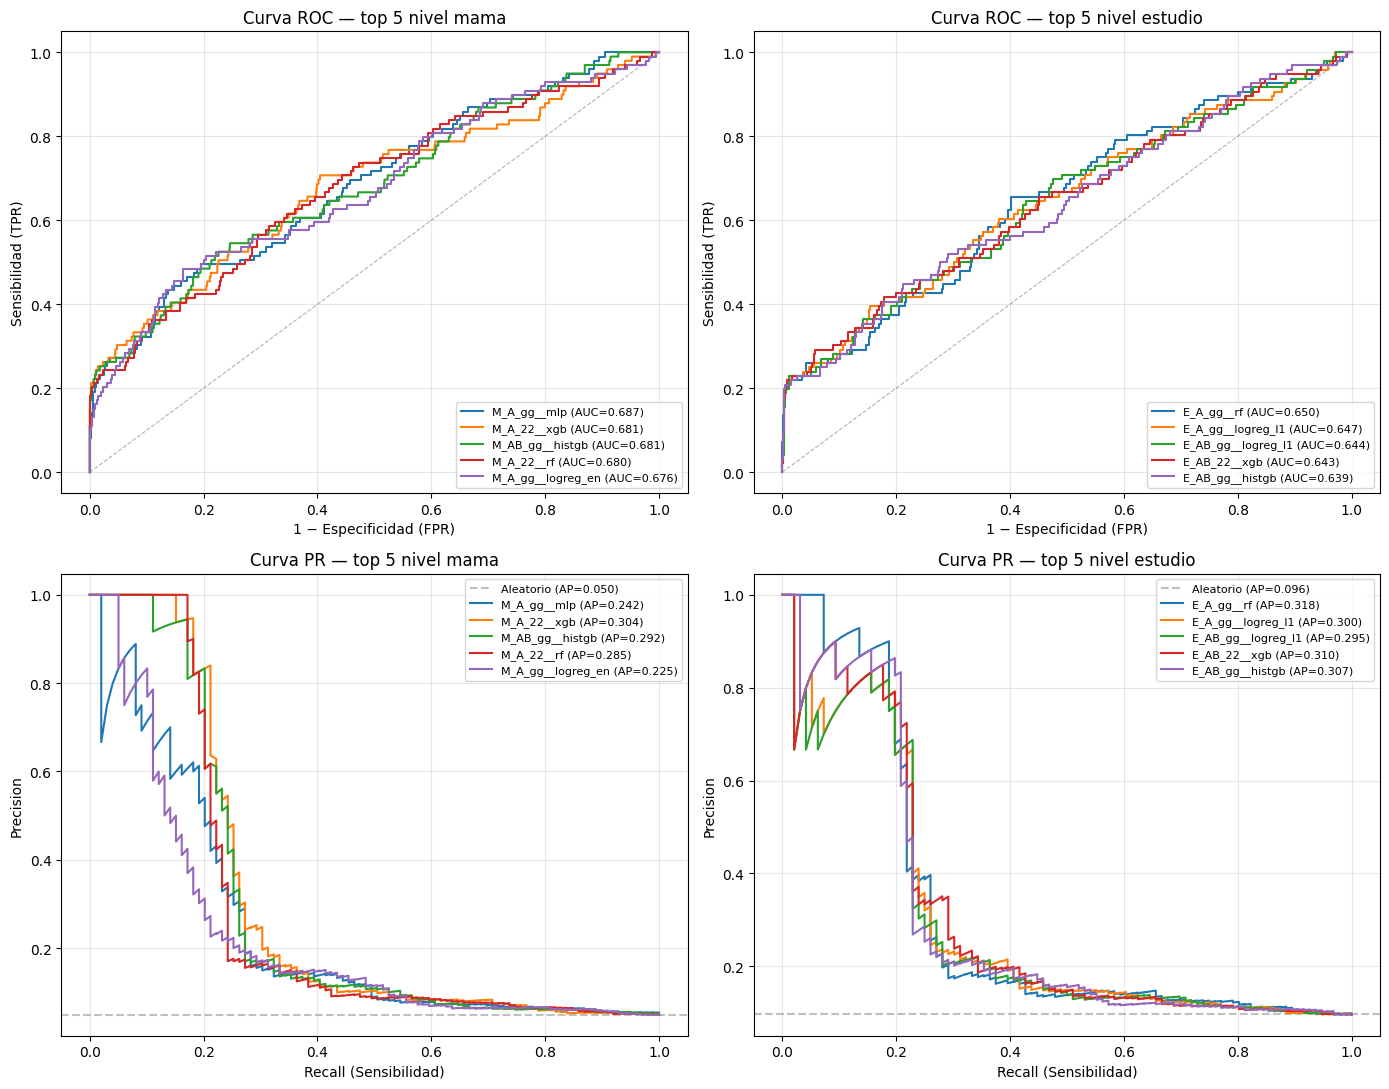

Guardado: curvas_top.png


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for col, level in enumerate(['mama', 'estudio']):
    top5 = df_eval[df_eval.level == level].nlargest(5, 'auc')
    y_test = y_M_test if level == 'mama' else y_E_test
    
    # ROC
    ax = axes[0, col]
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=0.8)
    for _, r in top5.iterrows():
        _, pred = load_predictions(r['config'], r['head'])
        fpr, tpr, _ = roc_curve(y_test, pred)
        ax.plot(fpr, tpr, label=f'{r["config"]}__{r["head"]} (AUC={r["auc"]:.3f})', linewidth=1.5)
    ax.set_xlabel('1 − Especificidad (FPR)')
    ax.set_ylabel('Sensibilidad (TPR)')
    ax.set_title(f'Curva ROC — top 5 nivel {level}')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    
    # PR
    ax = axes[1, col]
    prevalencia = y_test.mean()
    ax.axhline(prevalencia, color='gray', linestyle='--', alpha=0.5, label=f'Aleatorio (AP={prevalencia:.3f})')
    for _, r in top5.iterrows():
        _, pred = load_predictions(r['config'], r['head'])
        prec, rec, _ = precision_recall_curve(y_test, pred)
        ax.plot(rec, prec, label=f'{r["config"]}__{r["head"]} (AP={r["ap"]:.3f})', linewidth=1.5)
    ax.set_xlabel('Recall (Sensibilidad)')
    ax.set_ylabel('Precision')
    ax.set_title(f'Curva PR — top 5 nivel {level}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PRED_DIR_V2, 'curvas_top.png'), dpi=140, bbox_inches='tight')
plt.show()
print(f'Guardado: curvas_top.png')

## 12. Resumen

In [22]:
print('\n1. MEJORES CONFIGURACIONES (test AUC + IC95%)')
for level in ['mama', 'estudio']:
    top3 = df_eval[df_eval.level == level].nlargest(3, 'auc')
    print(f'\nNivel {level}:')
    for _, r in top3.iterrows():
        print(f'{r["config"]:14s} + {r["head"]:12s}, AUC={r["auc"]:.4f} [{r["auc_lo"]:.4f}, {r["auc_hi"]:.4f}], AP={r["ap"]:.4f}, Brier={r["brier"]:.4f}, ECE={r["ece"]:.4f}')

print('\n2. HALLAZGOS METODOLOGICOS (DeLong)')
for tipo in df_delong['tipo'].unique():
    sub = df_delong[df_delong['tipo'] == tipo]
    sig = sub[sub['significativo_005']]
    delta_mean = sub['delta'].mean()
    sign = 'primero gana' if delta_mean > 0 else 'segundo gana'
    print(f'{tipo:20s}: {len(sig)}/{len(sub)} significativos  d medio = {delta_mean:+.4f} ({sign} en promedio)')

print('\n3. CALIBRACION DEL TOP NIVEL MAMA')
best_mama = df_eval[df_eval.level == 'mama'].nlargest(1, 'auc').iloc[0]
print(f'{best_mama["config"]}__{best_mama["head"]}: Brier={best_mama["brier"]:.4f}, ECE={best_mama["ece"]:.4f}')
print('(Si Brier > 0.15 o ECE > 0.1, el NB12 de calibracion Platt/isotonica mejorara estos numeros)')

print(' Archivos generados:')
for f in ['eval_completo.csv', 'delong_pareado.csv', 'eval_densidad.csv', 'eval_edad.csv', 'auc_pairwise_birads.csv',
          'eval_densidad_modelo_final.csv', 'eval_edad_modelo_final.csv', 'matrices_confusion_modelo_final.csv', 'post_hoc_mama_to_estudio.csv']:
    path = os.path.join(PRED_DIR_V2, f)
    estado = 'OK' if os.path.isfile(path) else 'FALTA'
    print(f'{estado} {f}')


1. MEJORES CONFIGURACIONES (test AUC + IC95%)

Nivel mama:
M_A_gg         + mlp         , AUC=0.6866 [0.6289, 0.7417], AP=0.2422, Brier=0.1943, ECE=0.3811
M_A_22         + xgb         , AUC=0.6813 [0.6181, 0.7440], AP=0.3036, Brier=0.1175, ECE=0.2755
M_AB_gg        + histgb      , AUC=0.6811 [0.6189, 0.7412], AP=0.2915, Brier=0.0649, ECE=0.1468

Nivel estudio:
E_A_gg         + rf          , AUC=0.6499 [0.5879, 0.7119], AP=0.3178, Brier=0.0753, ECE=0.0206
E_A_gg         + logreg_l1   , AUC=0.6465 [0.5759, 0.7111], AP=0.3002, Brier=0.2163, ECE=0.3560
E_AB_gg        + logreg_l1   , AUC=0.6437 [0.5750, 0.7059], AP=0.2950, Brier=0.2228, ECE=0.3667

2. HALLAZGOS METODOLOGICOS (DeLong)
pool_2x2_vs_gg      : 4/42 significativos  d medio = -0.0169 (segundo gana en promedio)
AB_vs_A             : 0/34 significativos  d medio = -0.0061 (segundo gana en promedio)

3. CALIBRACION DEL TOP NIVEL MAMA
M_A_gg__mlp: Brier=0.1943, ECE=0.3811
(Si Brier > 0.15 o ECE > 0.1, el NB12 de calibracion Platt/iso